In [1]:
# ==============================
# Cell 1: Imports
# ==============================
import numpy as np
import matplotlib.pyplot as plt

# Random generator for reproducibility
rng = np.random.default_rng(42)


In [2]:
# ==============================
# Cell 2: Generate synthetic LIG data
# ==============================

n = 50  # number of LIG samples

# X = Laser fluence (J/cm²)
X = rng.uniform(1.5, 4.0, n)

# Y1 = ID/IG ratio (linearly decreasing with fluence)
Y1 = 1.1 - 0.15*X + rng.normal(0, 0.03, n)

# Y2 = Scaled version of Y1 (to show covariance depends on units)
Y2 = 100*Y1

# Y3 = Nonlinear relationship (quadratic)
Y3 = 0.5*X**2 + rng.normal(0, 0.1, n)


In [3]:
# ==============================
# Cell 3: Covariance and correlation
# ==============================

# Covariance
cov_XY1 = np.cov(X, Y1, bias=False)[0,1]
cov_XY2 = np.cov(X, Y2, bias=False)[0,1]
cov_XY3 = np.cov(X, Y3, bias=False)[0,1]

# Correlation coefficient (Pearson)
corr_XY1 = np.corrcoef(X, Y1)[0,1]
corr_XY2 = np.corrcoef(X, Y2)[0,1]
corr_XY3 = np.corrcoef(X, Y3)[0,1]

print("Covariance values:")
print(f"cov(X, Y1) = {cov_XY1:.2f}")
print(f"cov(X, Y2) = {cov_XY2:.2f}  # larger due to scaling")
print(f"cov(X, Y3) = {cov_XY3:.2f}  # nonlinear, positive but less meaningful")

print("\nCorrelation coefficients:")
print(f"corr(X, Y1) = {corr_XY1:.2f}")
print(f"corr(X, Y2) = {corr_XY2:.2f}  # same as Y1, unaffected by scale")
print(f"corr(X, Y3) = {corr_XY3:.2f}  # near 0 for nonlinear relationship")


Covariance values:
cov(X, Y1) = -0.07
cov(X, Y2) = -7.31  # larger due to scaling
cov(X, Y3) = 1.38  # nonlinear, positive but less meaningful

Correlation coefficients:
corr(X, Y1) = -0.98
corr(X, Y2) = -0.98  # same as Y1, unaffected by scale
corr(X, Y3) = 0.99  # near 0 for nonlinear relationship


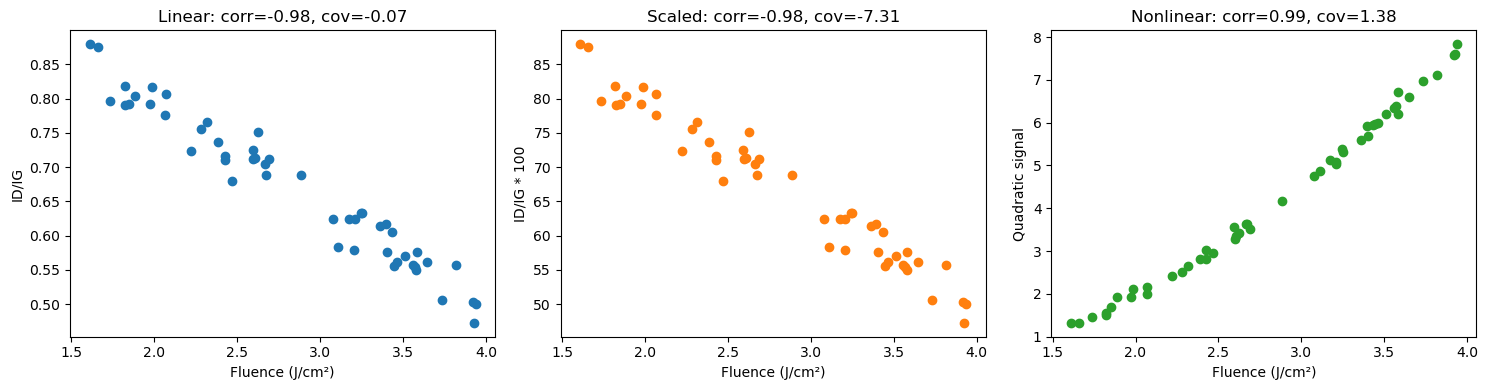

In [4]:
# ==============================
# Cell 4: Scatter plots
# ==============================

plt.figure(figsize=(15,4))

# Linear
plt.subplot(1,3,1)
plt.scatter(X, Y1, color='C0')
plt.title(f"Linear: corr={corr_XY1:.2f}, cov={cov_XY1:.2f}")
plt.xlabel("Fluence (J/cm²)")
plt.ylabel("ID/IG")

# Scaled linear
plt.subplot(1,3,2)
plt.scatter(X, Y2, color='C1')
plt.title(f"Scaled: corr={corr_XY2:.2f}, cov={cov_XY2:.2f}")
plt.xlabel("Fluence (J/cm²)")
plt.ylabel("ID/IG * 100")

# Nonlinear
plt.subplot(1,3,3)
plt.scatter(X, Y3, color='C2')
plt.title(f"Nonlinear: corr={corr_XY3:.2f}, cov={cov_XY3:.2f}")
plt.xlabel("Fluence (J/cm²)")
plt.ylabel("Quadratic signal")

plt.tight_layout()
plt.show()


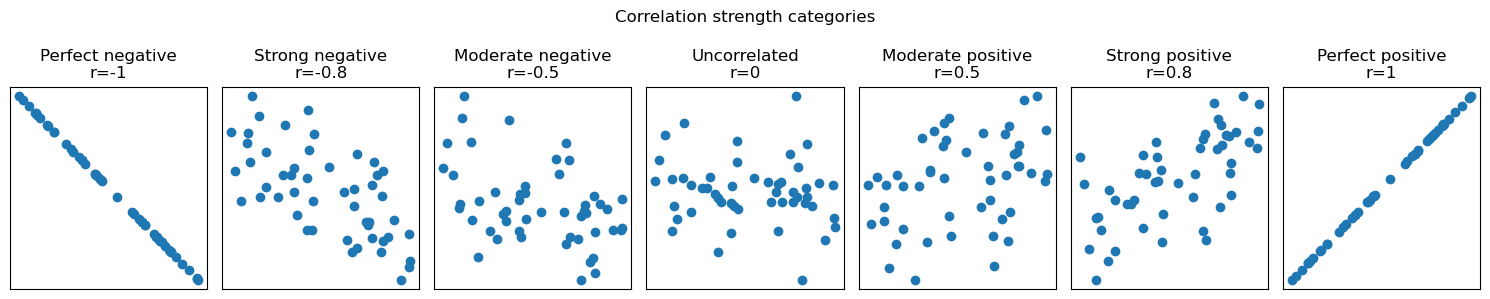

In [5]:
# ==============================
# Cell 5: Correlation strength demonstration using LIG linear data
# ==============================

strengths = [(-1,"Perfect negative"), 
             (-0.8,"Strong negative"), 
             (-0.5,"Moderate negative"), 
             (0,"Uncorrelated"), 
             (0.5,"Moderate positive"), 
             (0.8,"Strong positive"), 
             (1,"Perfect positive")]

plt.figure(figsize=(15,3))

for i,(r,label) in enumerate(strengths):
    if abs(r)==1:
        Y = r*X
    else:
        noise_std = np.sqrt(1-r**2)
        Y = r*X + rng.normal(0, noise_std, n)
    plt.subplot(1,7,i+1)
    plt.scatter(X,Y,color='C0')
    plt.title(label + f"\nr={r}")
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Correlation strength categories")
plt.tight_layout()
plt.show()


In [ ]:
#Key Lessons from This Demo Covariance depends on units and scale → not good for comparing different variable pairs
#Correlation coefficient normalizes covariance → dimensionless, ranges [-1,1]
#Linear relationship: correlation ~ ±1, scatter near a line
#No linear relationship: correlation ~0, even if variables are related nonlinearly
#Scaling does not affect correlation, but strongly affects covariance
#Correlation ≠ causation → need physical intuition to interpret